# Data Pre-Processing

## Module Imports

In [43]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


## Data Import

In [44]:
chunksFilePath = Path("GlobalGeoTree-6M/Chunks1Pixel/")

df = torch.load(chunksFilePath / 'SampledData-10Percent.pth', map_location="cpu", weights_only=False)

In [45]:
# Reorder columns to move imgData to the end
cols = [col for col in df.columns if col != 'imgData'] + ['imgData']
df = df[cols]

geoVars = ['latitude', 'longitude', 'elevation', 'slope', 'aspect']
levelVars = ['level0', 'level1_family', 'level2_genus', 'level3_species']
numericCols = [col for col in df.columns if col not in levelVars + ['ID', 'imgData']]

In [46]:
# remove rows with level3_species that occur rarely in entire df
speciesCounts = df['level3_species'].value_counts()
speciesToKeep = speciesCounts[speciesCounts > 1].index
df = df[df['level3_species'].isin(speciesToKeep)]

dfTrain, dfTest = train_test_split(df, test_size=0.2, stratify=df['level3_species'], random_state=0)

# Outliers

## Numeric Predictors
- Do not winsorisation geographic variables due to real world meaning
    - and no obvious outliers from inspection
- very mild winsorisation as few obvious outliers, many varaibles with heavy tails

In [47]:
colsToWins = [col for col in dfTrain.columns if col not in geoVars+levelVars+['ID', 'imgData']]

colsToWinsRangesBefore = dfTrain[colsToWins].max() - dfTrain[colsToWins].min()

winsPercentile = 0.005

for col in colsToWins:
    lower = dfTrain[col].quantile(winsPercentile)
    upper = dfTrain[col].quantile(1 - winsPercentile)
    dfTrain[col] = dfTrain[col].clip(lower=lower, upper=upper)
    dfTest[col] = dfTest[col].clip(lower=lower, upper=upper)

colsToWinsRangesAfter = dfTrain[colsToWins].max() - dfTrain[colsToWins].min()

#range reduction ratios
colsRRR = colsToWinsRangesBefore / colsToWinsRangesAfter
colsRRR = colsRRR.sort_values(ascending=False)

(0.0, 3.7869641304016115)

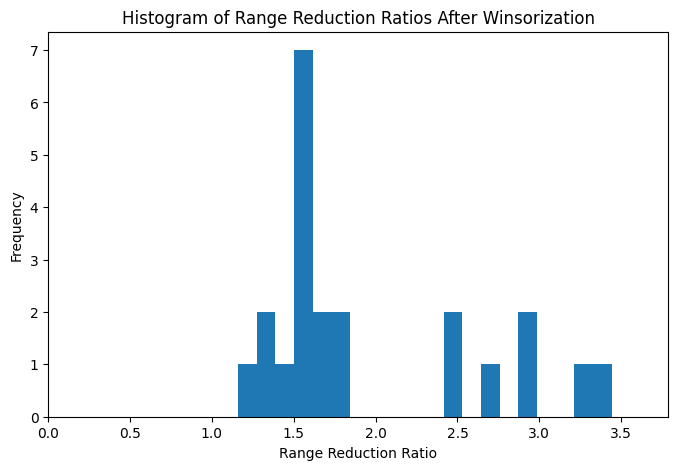

In [48]:
figColRR, axColRR = plt.subplots(figsize=(8, 5))
axColRR.hist(colsRRR, bins=20)
axColRR.set_title('Histogram of Range Reduction Ratios After Winsorization')
axColRR.set_xlabel('Range Reduction Ratio')
axColRR.set_ylabel('Frequency')
axColRR.set_xlim(0, max(colsRRR)*1.1)

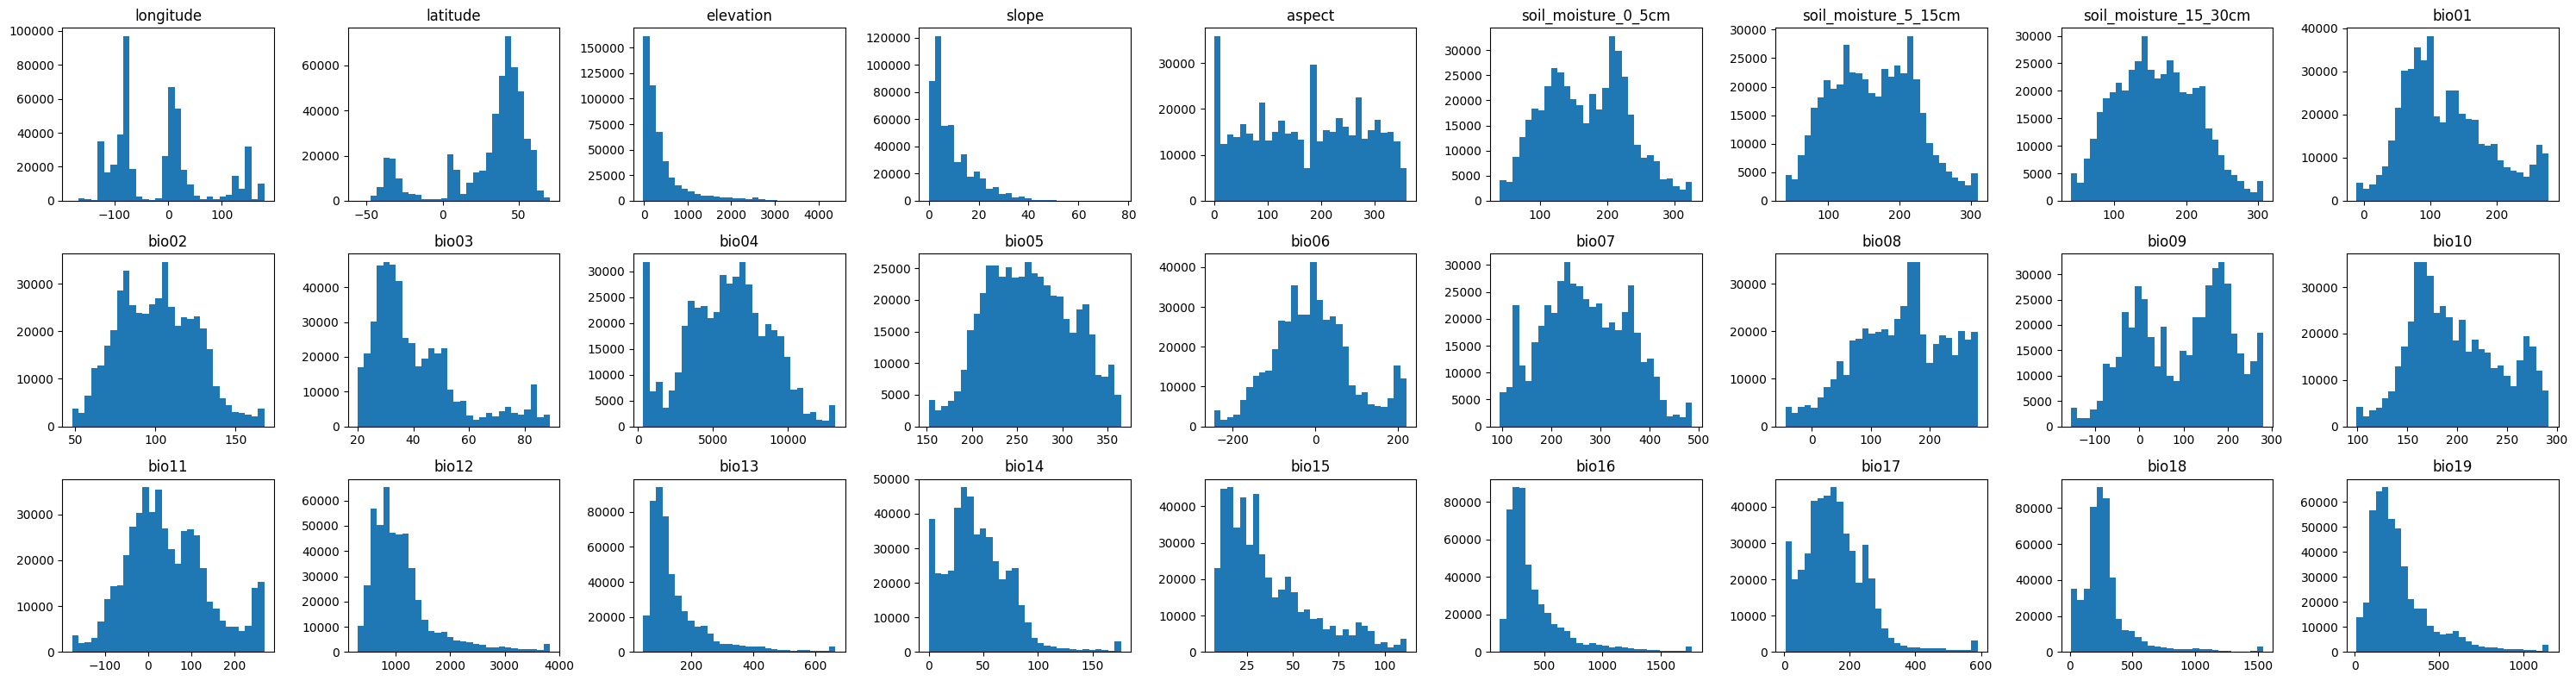

In [49]:
figDist, axDist = plt.subplots(nrows = 3, ncols=9, figsize=(30,8))

for i, col in enumerate(numericCols):
    a = i // 9
    b = i % 9
    ax = axDist[a, b]
    ax.hist(dfTrain[col].dropna().values, bins=30)
    ax.set_title(col)

figDist.tight_layout()

Tails notably reduced

## Image Data

- All distributions are heavily right skewed so winsorise on that tail only

In [50]:
allImgData = torch.stack(list(dfTrain['imgData'].values), dim=0)
allImgDataFlat = allImgData.view(-1, allImgData.shape[2])
allImgDataFlat.shape

torch.Size([5899632, 10])

In [51]:
# Min/max per band ignoring NaNs (compatible with older torch)
mask = ~torch.isnan(allImgDataFlat)
safe_min = torch.where(mask, allImgDataFlat, torch.tensor(float('inf')))
safe_max = torch.where(mask, allImgDataFlat, torch.tensor(float('-inf')))
band_min = safe_min.min(dim=0).values
band_max = safe_max.max(dim=0).values

imgRangesBefore = band_max - band_min


imgQuant_upper = torch.zeros(allImgDataFlat.shape[1])

for i in range(allImgDataFlat.shape[1]):
    band_data = allImgDataFlat[:, i]
    # Filter out NaNs
    valid_data = band_data[~torch.isnan(band_data)]
    imgQuant_upper[i] = torch.quantile(valid_data, 1 - winsPercentile*2)



In [52]:
# Apply winsorization to each tensor in df['imgData'] using per-band quantiles
def winsorize_tensor(t, upper_bounds):
    """Apply per-band winsorization to a tensor, preserving NaNs"""
    t_wins = t.clone()
    for i in range(t.shape[1]):  # iterate over bands (columns)
        t_wins[:, i] = torch.clamp(t_wins[:, i],  max=upper_bounds[i])
    return t_wins


dfTrain['imgData'] = dfTrain['imgData'].apply(lambda t: winsorize_tensor(t, imgQuant_upper))
dfTest['imgData'] = dfTest['imgData'].apply(lambda t: winsorize_tensor(t, imgQuant_upper))

allImgData_wins = torch.stack(list(dfTrain['imgData'].values), dim=0)
allImgDataFlat_wins = allImgData_wins.view(-1, allImgData_wins.shape[2])

# Check ranges after winsorization
safe_min_after = torch.where(~torch.isnan(allImgDataFlat_wins), allImgDataFlat_wins, torch.tensor(float('inf')))
safe_max_after = torch.where(~torch.isnan(allImgDataFlat_wins), allImgDataFlat_wins, torch.tensor(float('-inf')))
band_min_after = safe_min_after.min(dim=0).values
band_max_after = safe_max_after.max(dim=0).values
imgRangesAfter = band_max_after - band_min_after

imgRangesBefore / imgRangesAfter

tensor([3.3159, 3.1398, 2.9911, 2.4665, 4.2463, 2.6060, 2.5585, 2.5072, 3.2559,
        3.8647], dtype=torch.float64)

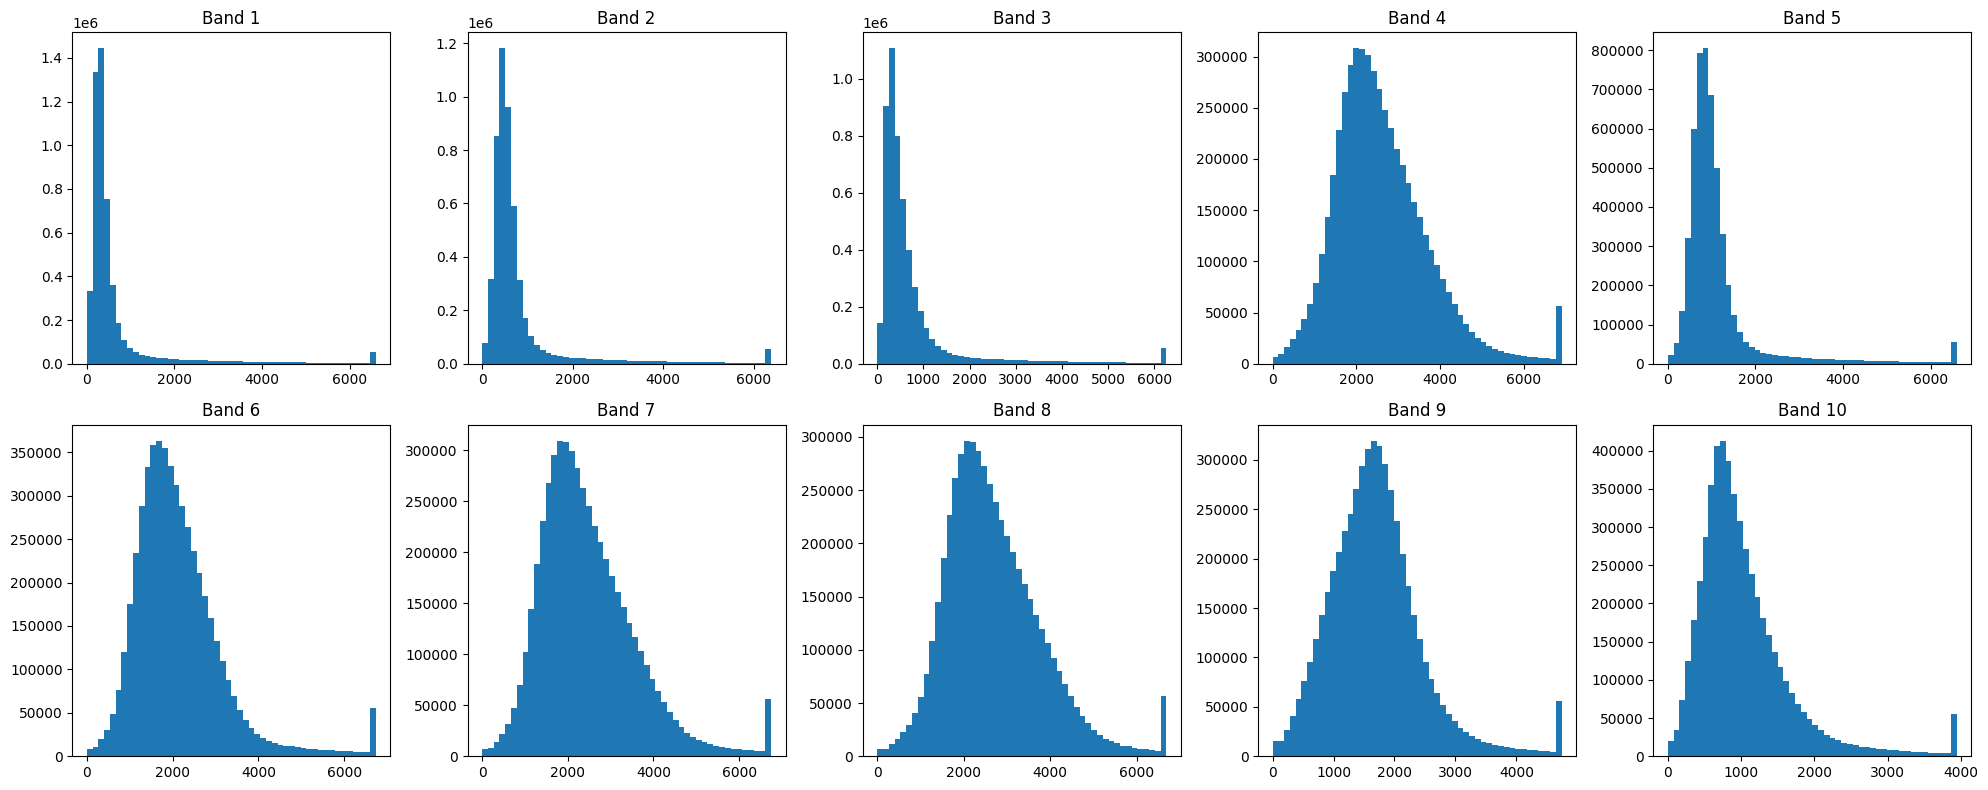

In [53]:
figImgDist, axImgDist = plt.subplots(nrows=2, ncols=5, figsize=(20,8))

for i in range(allImgDataFlat_wins.shape[1]):
    ax = axImgDist[i // 5, i % 5]
    ax.hist(allImgDataFlat_wins[:, i].numpy(), bins=50)
    ax.set_title(f'Band {i+1}')
    #ax.set_xscale('log')

figImgDist.tight_layout()

Significant improvement in distribution shape, bands 1-3 still are quite narrow

# Missing Values

## Numeric Predictors

In [54]:
rowMissingPropTrain = dfTrain[numericCols].isna().sum(axis=1)/dfTrain[numericCols].shape[1]
rowMissingPropTest = dfTest[numericCols].isna().sum(axis=1)/dfTest[numericCols].shape[1]
rowMissingPropNo0 = rowMissingPropTrain[rowMissingPropTrain != 0.0]

rowMissingPropTrain.describe()

count    491636.000000
mean          0.025100
std           0.114031
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
dtype: float64

In [55]:
# drop rows with misingness greater than 50%
mask = rowMissingPropTrain.loc[dfTrain.index] <= 0.5
dfTrain = dfTrain.loc[mask]

mask = rowMissingPropTest.loc[dfTest.index] <= 0.5
dfTest = dfTest.loc[mask]

# Recalculate numericCols after filtering to match current dataframe
numericCols = [col for col in dfTrain.columns if col not in levelVars + ['ID', 'imgData']]

speciesImputers = {}

# KNN imputation filtered by species for other missing numeric data
def impute_species_group(group):
    """Impute missing values within a species group"""
    group = group.copy()
    species = group['level3_species'].iloc[0]


    # Skip groups that are too small
    if group.shape[0] < 6:
        return group
    
    
    # Define numeric columns within this function to avoid scope issues
    cols_to_impute = [col for col in group.columns
    if col not in levelVars + ['ID', 'imgData']
    and not group[col].isna().all()]

    valid_rows = group[cols_to_impute].notna().any(axis=1).sum()
    if valid_rows <= 5:
        return group
    
    k = min(5, group.shape[0] - 1)
    imputer = KNNImputer(n_neighbors=k, weights='distance')

    imputed_array = imputer.fit_transform(group[cols_to_impute])

    speciesImputers[species] = {'imputer': imputer, 'cols': cols_to_impute}
    
    # Assign imputed values back using iloc
    imputed_df = pd.DataFrame(imputed_array, columns=cols_to_impute, index=group.index)
    group[cols_to_impute] = imputed_df
    
    return group

def impute_species_group_test(group):
    group = group.copy()
    species = group['level3_species'].iloc[0]

    # If species was never seen or imputer not fitted, skip
    if species not in speciesImputers:
        return group

    imputer_info = speciesImputers[species]
    imputer = imputer_info["imputer"]
    cols_to_impute = imputer_info["cols"]

    # Ensure column alignment
    cols_to_impute = [c for c in cols_to_impute if c in group.columns]

    if len(cols_to_impute) == 0:
        return group

    imputed_array = imputer.transform(group[cols_to_impute])
    group.loc[:, cols_to_impute] = imputed_array

    return group


print("Missing values before species-grouped KNN imputation:")
print(dfTrain[numericCols].isna().sum().sum())

dfTrain = dfTrain.groupby('level3_species', group_keys=False).apply(impute_species_group, include_groups=True)
dfTest = (dfTest.groupby('level3_species', group_keys=False).apply(impute_species_group_test, include_groups=True))


# Verify imputation results
print("Missing values after species-grouped KNN imputation:")
print(dfTrain[numericCols].isna().sum().sum())
print(f"\nRows affected: {dfTrain[numericCols].isna().any(axis=1).sum()} rows with any remaining missing values")

Missing values before species-grouped KNN imputation:
124875


C:\Users\yy21473\AppData\Local\Temp\ipykernel_9444\3052468197.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dfTrain = dfTrain.groupby('level3_species', group_keys=False).apply(impute_species_group, include_groups=True)


Missing values after species-grouped KNN imputation:
1410

Rows affected: 465 rows with any remaining missing values


C:\Users\yy21473\AppData\Local\Temp\ipykernel_9444\3052468197.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dfTest = (dfTest.groupby('level3_species', group_keys=False).apply(impute_species_group_test, include_groups=True))


In [56]:
# drop rows that still have any missing numeric data
dfTrain = dfTrain.dropna(subset=numericCols)
dfTest = dfTest.dropna(subset=numericCols)




# Image Data

### Drop if > 50% missing

In [57]:
def nanProp(t):
    if isinstance(t, torch.Tensor) and t.is_floating_point():
        return torch.isnan(t).sum().item()/120
    return 0

dfTrain['img_nan_prop'] = dfTrain['imgData'].apply(nanProp)
dfTest['img_nan_prop'] = dfTest['imgData'].apply(nanProp)
dfTrain['img_nan_prop'].describe()




count    481432.000000
mean          0.119188
std           0.138629
min           0.000000
25%           0.000000
50%           0.083333
75%           0.166667
max           1.000000
Name: img_nan_prop, dtype: float64

In [58]:
mask = dfTrain['img_nan_prop'] <= 0.5
dfTrain = dfTrain.loc[mask]

mask = dfTest['img_nan_prop'] <= 0.5
dfTest = dfTest.loc[mask]

dfTrain['img_nan_prop'].describe()

count    466105.000000
mean          0.103271
std           0.108700
min           0.000000
25%           0.000000
50%           0.083333
75%           0.166667
max           0.500000
Name: img_nan_prop, dtype: float64

In [59]:
# check also if any rows have NaN for all months in a single band
def nanBand(t):
    '''returns how many months have data missing for all bands'''
    if isinstance(t, torch.Tensor) and t.is_floating_point():
        return torch.isnan(t).sum(axis=0).max().item()
    return 0

dfTrain['img_nan_band'] = dfTrain['imgData'].apply(nanBand)
dfTest['img_nan_band'] = dfTest['imgData'].apply(nanBand)
dfTrain['img_nan_band'].describe()

count    466105.000000
mean          1.239249
std           1.304395
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: img_nan_band, dtype: float64

In [60]:
mask = dfTrain['img_nan_band'] <= 9 #requires there to be at least 3 months of image data present
dfTrain = dfTrain.loc[mask]

mask = dfTest['img_nan_band'] <= 9
dfTest = dfTest.loc[mask]


dfTrain['img_nan_band'].describe()

count    466105.000000
mean          1.239249
std           1.304395
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: img_nan_band, dtype: float64

No change here as previous drop took care of it. At most 6 months of image data is missing

### Mean imputation of missing data per band in that image

In [61]:
allImgDataTrain = torch.stack(list(dfTrain['imgData'].values), dim=0).view(-1, allImgData.shape[2])
imgDataMeans = torch.nanmean(allImgDataTrain, dim=0)



In [62]:
def mean_impute(t):
    if isinstance(t, torch.Tensor) and t.is_floating_point():
        #nan_mean = t.nanmean(axis=0)
        #print(nan_mean.shape)
        t_filled = t.clone()
        nan_mask = torch.isnan(t)
        t_filled[nan_mask] = imgDataMeans.expand_as(t)[nan_mask]
        return t_filled
    return t

dfTrain['imgDataImputed'] = dfTrain['imgData'].apply(mean_impute)
dfTest['imgDataImputed'] = dfTest['imgData'].apply(mean_impute)



In [63]:
dfTrain['img_nan_prop_afterImpute'] = dfTrain['imgDataImputed'].apply(nanProp)
dfTrain['img_nan_prop_afterImpute'].describe()

count    466105.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: img_nan_prop_afterImpute, dtype: float64

In [64]:
dfTrain.isna().sum().sum()

np.int64(0)

Not a single NaN left!

# Distribution Transformations
- decided not needed, minimal skews or very long tails present

# Scaling

## Numeric Predictors

In [65]:
# Scale all numeric columns to [0, 1]
scaler = MinMaxScaler()
dfTrain[numericCols] = scaler.fit_transform(dfTrain[numericCols])
dfTest[numericCols] = scaler.transform(dfTest[numericCols])


## Image Data

In [66]:
# flatten imgDataImputed and find min/max across all data
allImgDataImputed = torch.stack(list(dfTrain['imgDataImputed'].values), dim=0)
allImgDataFlatImputed = allImgDataImputed.view(-1, allImgDataImputed.shape[2]) 

imgMins = allImgDataFlatImputed.min(dim=0).values
imgMaxs = allImgDataFlatImputed.max(dim=0).values

# Scale each tensor to [0, 1] using per-band min/max with vectorized operations
def scale_tensor(t, mins, maxs):
    """Scale tensor to [0, 1] using per-band min/max values with vectorized operations"""
    ranges = maxs - mins
    # Avoid division by zero by setting zero ranges to 1
    ranges = torch.where(ranges > 0, ranges, torch.ones_like(ranges))
    scaled = (t - mins) / ranges
    #print(scaled.min(), scaled.max())
    return scaled

dfTrain['imgDataScaled'] = dfTrain['imgDataImputed'].apply(lambda t: scale_tensor(t, imgMins, imgMaxs))
dfTest['imgDataScaled'] = dfTest['imgDataImputed'].apply(lambda t: scale_tensor(t, imgMins, imgMaxs))


# Small Classes

- Will be very hard to predict and just add noise

In [67]:
minClassSize = 5 #inclusive

# remove rows with level3_species that occur rarely in training set
speciesCountsTrain = dfTrain['level3_species'].value_counts()
speciesCountsTest = dfTest['level3_species'].value_counts()

#keep only species that meet minClassSize in train set and remove species from test set that are not in train set
speciesToKeepTrain = speciesCountsTrain[speciesCountsTrain >= minClassSize].index
dfTrain = dfTrain[dfTrain['level3_species'].isin(speciesToKeepTrain)]
dfTest = dfTest[dfTest['level3_species'].isin(speciesToKeepTrain)]



In [68]:
# validate smallest class sizes per level
valueCounts = []

for level in levelVars:
    vc = dfTrain[level].value_counts().reset_index()
    vc.columns = [level, 'count']
    vc['level'] = level
    valueCounts.append(vc)

# minimum value frequency per level
for vc in valueCounts:
    min_count = vc['count'].min()
    level = vc['level'].iloc[0]
    print(f"Minimum frequency for {level}: {min_count}, occurrences: {vc[vc['count'] == min_count].shape[0]}")

Minimum frequency for level0: 1935, occurrences: 1
Minimum frequency for level1_family: 5, occurrences: 4
Minimum frequency for level2_genus: 5, occurrences: 45
Minimum frequency for level3_species: 5, occurrences: 288


# Flatten Images

In [69]:
# Extract tensor data into 120 new columns (10 bands × 12 months)
num_months = 12
num_bands = 10

column_names = [f"Band_{b:02d}_Month_{m:02d}" for b in range(num_bands) for m in range(num_months)]

tensor_dataTrain = dfTrain['imgDataScaled'].apply(lambda tensor: tensor.T.flatten().numpy().astype(np.float32))
tensor_dfTrain = pd.DataFrame(tensor_dataTrain.tolist(), columns=column_names)

tensor_dataTest = dfTest['imgDataScaled'].apply(lambda tensor: tensor.T.flatten().numpy().astype(np.float32))
tensor_dfTest = pd.DataFrame(tensor_dataTest.tolist(), columns=column_names)

dfTrain = pd.concat([dfTrain.reset_index(drop=True), tensor_dfTrain], axis=1)
dfTest = pd.concat([dfTest.reset_index(drop=True), tensor_dfTest], axis=1)
#df.drop(columns=['imgDataScaled'], inplace=True)
 
print(f"New dataframe shape: {dfTrain.shape}")

New dataframe shape: (458481, 158)


# Data Export

In [ ]:
dfTrain.sort_values('ID')
dfTest.sort_values('ID')


colsToDropTrain = ['imgData', 'imgDataImputed', 'imgDataScaled', 'img_nan_prop', 'img_nan_band', 'img_nan_prop_afterImpute']
dfTrain = dfTrain.drop(columns=colsToDropTrain)


KeyError: "['imgData', 'imgDataImputed', 'img_nan_prop', 'img_nan_band', 'img_nan_prop_afterImpute'] not found in axis"

In [73]:

colsToDrop = ['imgData', 'imgDataImputed',  'imgDataScaled', 'img_nan_prop', 'img_nan_band']
dfTest = dfTest.drop(columns=colsToDrop)
dfTrain.head()



,ID,longitude,latitude,elevation,slope,aspect,soil_moisture_0_5cm,soil_moisture_5_15cm,soil_moisture_15_30cm,bio01,...,Band_09_Month_02,Band_09_Month_03,Band_09_Month_04,Band_09_Month_05,Band_09_Month_06,Band_09_Month_07,Band_09_Month_08,Band_09_Month_09,Band_09_Month_10,Band_09_Month_11
0,2197969,0.621170,0.881777,0.040761,0.064935,0.752089,0.794896,0.646840,0.692884,0.183391,...,0.175263,0.263174,0.378152,0.161703,0.186288,0.180966,0.160436,0.193131,0.044354,0.007350
1,2196960,0.739576,0.851944,0.131341,0.129870,0.311978,0.568281,0.524163,0.546816,0.100346,...,0.178178,0.319478,0.270688,0.223673,0.165252,0.228108,0.257255,0.277531,0.186415,0.236979
2,2972526,0.151709,0.827662,0.014266,0.051948,0.250696,0.906460,0.836431,0.741573,0.352941,...,0.155494,0.133950,0.163097,0.640983,0.152199,0.140667,0.111773,0.628944,0.263174,0.050564
3,1605005,0.519282,0.900599,0.016304,0.025974,0.172702,0.575254,0.464684,0.393258,0.283737,...,0.294259,0.308199,0.213661,0.163224,0.157648,0.148650,0.148017,0.127740,0.177417,0.291725
4,582943,0.546077,0.829973,0.048460,0.012987,0.250696,0.271938,0.144981,0.146067,0.356401,...,0.289951,0.268027,0.202256,0.263174,0.176277,0.174883,0.184007,1.000000,0.220504,0.263174


In [78]:
dfTest.sort_values('ID', ascending=True)

print(dfTest.shape)

dfTest.head()

(114857, 152)


,ID,longitude,latitude,elevation,slope,aspect,soil_moisture_0_5cm,soil_moisture_5_15cm,soil_moisture_15_30cm,bio01,...,Band_09_Month_02,Band_09_Month_03,Band_09_Month_04,Band_09_Month_05,Band_09_Month_06,Band_09_Month_07,Band_09_Month_08,Band_09_Month_09,Band_09_Month_10,Band_09_Month_11
0,102649,0.552554,0.173556,0.081069,0.077922,0.030641,0.188265,0.200743,0.239700,0.591695,...,0.419592,0.379927,0.215055,0.183247,0.263174,0.263174,0.263174,0.258015,0.283488,0.302497
1,3728574,0.258674,0.708316,0.054801,0.103896,0.980501,0.554335,0.553903,0.573034,0.598616,...,0.263174,0.177924,0.196680,0.144722,0.195159,0.138132,0.155874,0.163984,0.191484,0.218984
2,5230398,0.911051,0.389820,0.068841,0.077922,0.000000,0.620577,0.672862,0.677903,0.906574,...,0.263174,0.244076,0.263174,0.276518,0.263174,0.263174,0.263174,0.272462,0.263174,0.356102
3,3452340,0.158935,0.762832,0.095335,0.246753,0.083565,0.365069,0.396878,0.433217,0.574394,...,0.160943,0.185781,0.185781,0.186035,0.176023,0.176023,0.175897,0.111393,0.087441,0.088709
4,2921105,0.158549,0.831874,0.194973,0.116883,0.857939,0.773978,0.851301,0.831461,0.238754,...,0.036751,0.283741,0.055253,0.263174,0.179191,0.192118,0.159422,0.120264,0.094031,0.029907


In [79]:
print(dfTrain.shape)

dfTrain.head()

(458481, 153)


,ID,longitude,latitude,elevation,slope,aspect,soil_moisture_0_5cm,soil_moisture_5_15cm,soil_moisture_15_30cm,bio01,...,Band_09_Month_02,Band_09_Month_03,Band_09_Month_04,Band_09_Month_05,Band_09_Month_06,Band_09_Month_07,Band_09_Month_08,Band_09_Month_09,Band_09_Month_10,Band_09_Month_11
0,2197969,0.621170,0.881777,0.040761,0.064935,0.752089,0.794896,0.646840,0.692884,0.183391,...,0.175263,0.263174,0.378152,0.161703,0.186288,0.180966,0.160436,0.193131,0.044354,0.007350
1,2196960,0.739576,0.851944,0.131341,0.129870,0.311978,0.568281,0.524163,0.546816,0.100346,...,0.178178,0.319478,0.270688,0.223673,0.165252,0.228108,0.257255,0.277531,0.186415,0.236979
2,2972526,0.151709,0.827662,0.014266,0.051948,0.250696,0.906460,0.836431,0.741573,0.352941,...,0.155494,0.133950,0.163097,0.640983,0.152199,0.140667,0.111773,0.628944,0.263174,0.050564
3,1605005,0.519282,0.900599,0.016304,0.025974,0.172702,0.575254,0.464684,0.393258,0.283737,...,0.294259,0.308199,0.213661,0.163224,0.157648,0.148650,0.148017,0.127740,0.177417,0.291725
4,582943,0.546077,0.829973,0.048460,0.012987,0.250696,0.271938,0.144981,0.146067,0.356401,...,0.289951,0.268027,0.202256,0.263174,0.176277,0.174883,0.184007,1.000000,0.220504,0.263174


In [80]:
torch.save(dfTrain, chunksFilePath / 'SampledData-10Percent-Clean-Train.pth')
torch.save(dfTest, chunksFilePath / 'SampledData-10Percent-Clean-Test.pth')

In [87]:
#dfTrain.drop(columns=['imgDataScaled'], inplace=True)

torch.save(dfTrain, chunksFilePath / 'SampledData-10Percent-Clean-Train.pth')